In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

%matplotlib inline

In [2]:
import pandas as pd

df = pd.read_csv("../scraper/books_raw.csv")

print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (105, 9)

Columns:
Index(['title', 'category', 'price', 'rating', 'availability',
       'product_description', 'UPC', 'number_of_reviews', 'product_url'],
      dtype='str')


In [3]:
df.head()

,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url
0,It's Only the Himalayas,Travel,£45.17,Two,In stock (19 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,0,https://books.toscrape.com/catalogue/its-only-...
1,Libertarianism for Beginners,Politics,£51.33,Two,In stock (19 available) In stock In stock In s...,Libertarianism isn't about winning elections; ...,a18a4f574854aced,0,https://books.toscrape.com/catalogue/libertari...
2,Mesaerion: The Best Science Fiction Stories 18...,Science Fiction,£37.59,One,In stock (19 available) In stock In stock In s...,"Andrew Barger, award-winning author and engine...",e30f54cea9b38190,0,https://books.toscrape.com/catalogue/mesaerion...
3,Olio,Poetry,£23.88,One,In stock (19 available) In stock In stock In s...,"Part fact, part fiction, Tyehimba Jess's much ...",feb7cc7701ecf901,0,https://books.toscrape.com/catalogue/olio_984/...
4,Our Band Could Be Your Life: Scenes from the A...,Music,£57.25,Three,In stock (19 available) In stock In stock In s...,This is the never-before-told story of the mus...,deda3e61b9514b83,0,https://books.toscrape.com/catalogue/our-band-...


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   title                105 non-null    str  
 1   category             105 non-null    str  
 2   price                105 non-null    str  
 3   rating               105 non-null    str  
 4   availability         105 non-null    str  
 5   product_description  105 non-null    str  
 6   UPC                  105 non-null    str  
 7   number_of_reviews    105 non-null    int64
 8   product_url          105 non-null    str  
dtypes: int64(1), str(8)
memory usage: 7.5 KB


In [5]:
df.describe(include="all")

,title,category,price,rating,availability,product_description,UPC,number_of_reviews,product_url
count,105,105,105,105,105,105,105,105.0,105
unique,105,29,104,5,7,105,105,NaN,105
top,It's Only the Himalayas,Sequential Art,£44.18,One,In stock (16 available) In stock In stock In s...,"“Wherever you go, whatever you do, just . . . ...",a22124811bfa8350,NaN,https://books.toscrape.com/catalogue/its-only-...
freq,1,16,2,23,64,1,1,NaN,1
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [6]:
import pandas as pd

df = pd.read_csv("../scraper/books_raw.csv")

df.shape

(105, 9)

In [7]:
df["price"] = df["price"].str.replace("£", "", regex=False)
df["price"] = df["price"].astype(float)

df["price"].head()

0    45.17
1    51.33
2    37.59
3    23.88
4    57.25
Name: price, dtype: float64

In [8]:
rating_map = {
    "One": 1,
    "Two": 2,
    "Three": 3,
    "Four": 4,
    "Five": 5
}

df["rating"] = df["rating"].map(rating_map)

df["rating"].head()

0    2
1    2
2    1
3    1
4    3
Name: rating, dtype: int64

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 105 entries, 0 to 104
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   title                105 non-null    str    
 1   category             105 non-null    str    
 2   price                105 non-null    float64
 3   rating               105 non-null    int64  
 4   availability         105 non-null    str    
 5   product_description  105 non-null    str    
 6   UPC                  105 non-null    str    
 7   number_of_reviews    105 non-null    int64  
 8   product_url          105 non-null    str    
dtypes: float64(1), int64(2), str(6)
memory usage: 7.5 KB


In [10]:
df.describe()

,price,rating,number_of_reviews
count,105.000000,105.000000,105.0
mean,34.598857,2.857143,0.0
std,14.401022,1.375811,0.0
min,10.160000,1.000000,0.0
25%,20.590000,2.000000,0.0
50%,34.530000,3.000000,0.0
75%,46.910000,4.000000,0.0
max,59.640000,5.000000,0.0


In [11]:
category_counts = df["category"].value_counts()

print(category_counts)

category
Sequential Art        16
Default               12
Nonfiction            12
Fantasy                6
Poetry                 5
Young Adult            5
Romance                5
History                4
Childrens              4
Food and Drink         4
Add a comment          4
Philosophy             3
Fiction                3
Science Fiction        2
Music                  2
Business               2
Thriller               2
Mystery                2
Spirituality           2
Travel                 1
Politics               1
Art                    1
Contemporary           1
New Adult              1
Horror                 1
Health                 1
Self Help              1
Religion               1
Historical Fiction     1
Name: count, dtype: int64


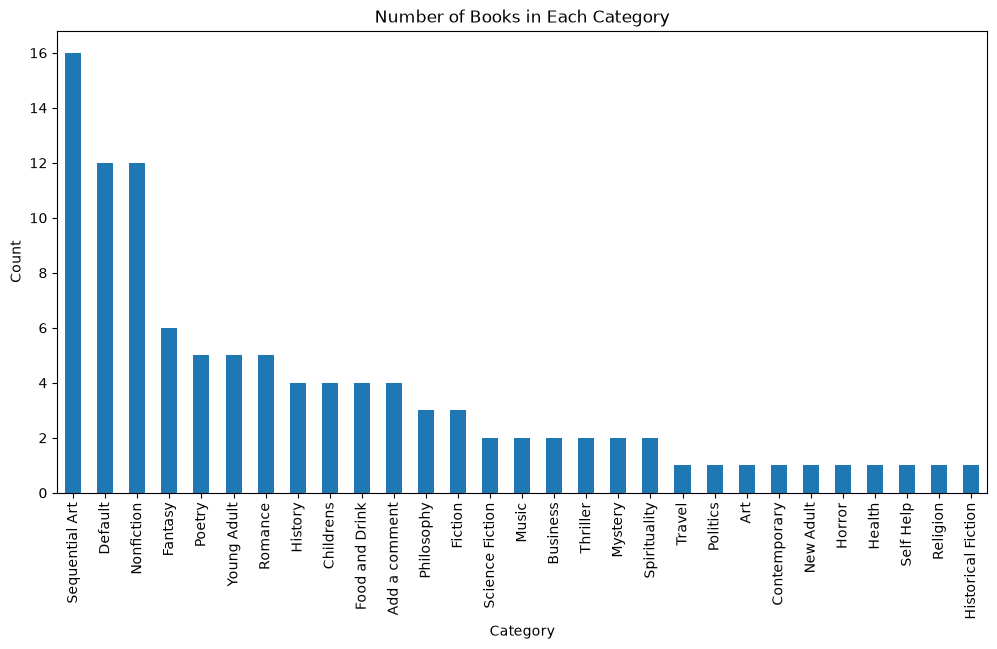

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
category_counts.plot(kind="bar")
plt.title("Number of Books in Each Category")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

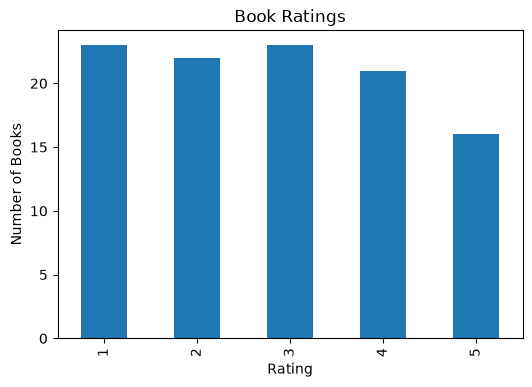

In [13]:
plt.figure(figsize=(6,4))
df["rating"].value_counts().sort_index().plot(kind="bar")
plt.title("Book Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Books")
plt.show()

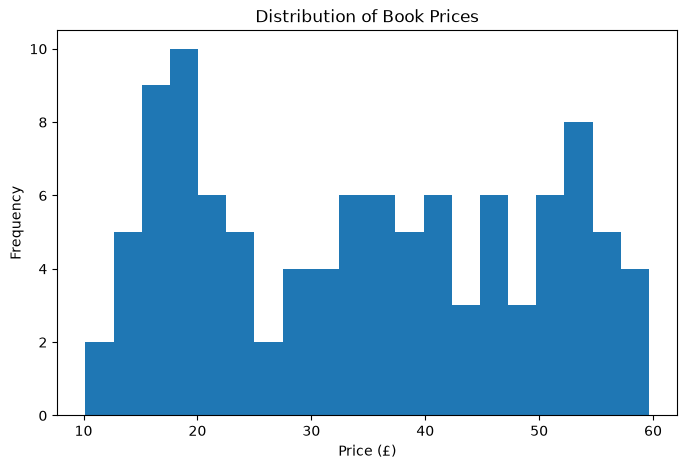

In [14]:
plt.figure(figsize=(8,5))
plt.hist(df["price"], bins=20)
plt.title("Distribution of Book Prices")
plt.xlabel("Price (£)")
plt.ylabel("Frequency")
plt.show()

In [15]:
top_books = df.sort_values("price", ascending=False)

top_books[["title", "price"]].head(10)

,title,price
102,Thomas Jefferson and the Tripoli Pirates: The ...,59.64
59,The Death of Humanity: and the Case for Life,58.11
100,The White Cat and the Monk: A Retelling of the...,58.08
4,Our Band Could Be Your Life: Scenes from the A...,57.25
33,The Past Never Ends,56.50
34,The Pioneer Woman Cooks: Dinnertime: Comfort C...,56.41
72,Masks and Shadows,56.40
35,The Secret of Dreadwillow Carse,56.13
60,The Electric Pencil: Drawings from Inside Stat...,56.06
30,Birdsong: A Story in Pictures,54.64


In [16]:
df.groupby("rating")["price"].mean()

rating
1    36.443043
2    36.916818
3    34.574348
4    33.250952
5    30.565000
Name: price, dtype: float64

In [17]:
df.groupby("rating")["price"].mean()

rating
1    36.443043
2    36.916818
3    34.574348
4    33.250952
5    30.565000
Name: price, dtype: float64

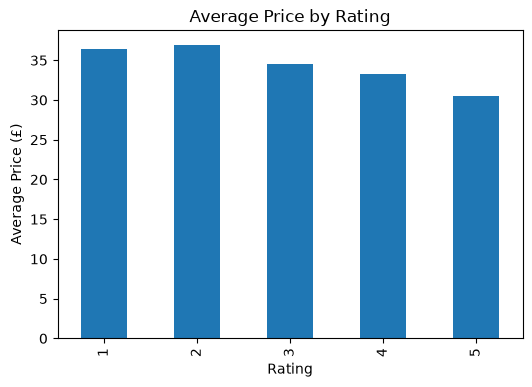

In [18]:
df.groupby("rating")["price"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Price by Rating")
plt.xlabel("Rating")
plt.ylabel("Average Price (£)")
plt.show()

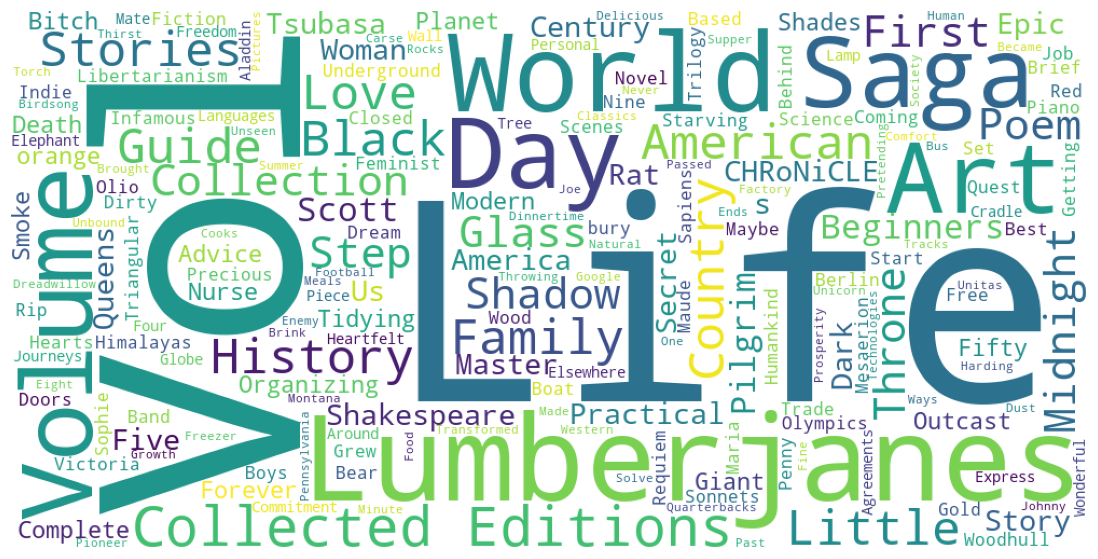

In [19]:
from wordcloud import WordCloud

text = " ".join(df["title"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(text)

plt.figure(figsize=(15,7))
plt.imshow(wordcloud)
plt.axis("off")
plt.show()

In [20]:
df.to_csv("books_cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!
